<a href="https://colab.research.google.com/github/SeiDra/lending-club-prediction/blob/scindage-du-notebook-FeatureEngineering%2FModeling/du_sda_ml2_P3_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJET 7 : Loan Default Prediction
Partie N°3 — Feature Engineering

Contenu :
- Import des données nettoyées (sortie du P2)
- Identification des types de variables
- Construction (7 ratios financiers métier documentés)
- Visualisation de la Corrélation des nouvelles features avec notre target
- Binary Encoding pour les variables binaires
- Train / Test Split stratifié 
- Recherche du smoothing optimal (TargetEncoder) par cross-validation
- Target Encoding avec le smoothing optimal (fit sur train uniquement)
- Normalisation StandardScaler (fit sur train uniquement)
- Vérifications étendues (NaN, inf, dtypes, distribution)
- Sauvegarde des jeux train/test, transformateurs et liste des features

In [6]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from category_encoders import TargetEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_parquet("DATA/cleaned_data_for_modeling.parquet")

# Lecture du nom de la cible depuis le fichier de configuration
with open("CONFIG/target_config.txt", "r") as f:
    target_col = f.read().strip()

print(f"Cible : {target_col}")
print(f"Dimensions du dataset : {df.shape}")
print(f"\nDistribution de la cible :")
print(df[target_col].value_counts())
print(df[target_col].value_counts(normalize=True) * 100)

Cible : loan_condition_int
Dimensions du dataset : (67230, 91)

Distribution de la cible :
loan_condition_int
0    54214
1    13016
Name: count, dtype: int64
loan_condition_int
0    80.639595
1    19.360405
Name: proportion, dtype: float64


###  Identification des types de variables

In [3]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = [col for col in df.select_dtypes(exclude=['object']).columns.tolist()
            if col != target_col]

binary_cat_cols = [col for col in cat_cols if df[col].nunique() <= 2]
multi_cat_cols = [col for col in cat_cols if df[col].nunique() > 2]

print(f"Variables numériques : {len(num_cols)}")
print(f"Variables catégorielles binaires : {len(binary_cat_cols)} → {binary_cat_cols}")
print(f"Variables catégorielles multi : {len(multi_cat_cols)} → {multi_cat_cols}")

Variables numériques : 76
Variables catégorielles binaires : 5 → ['term', 'pymnt_plan', 'initial_list_status', 'disbursement_method', 'loan_condition']
Variables catégorielles multi : 9 → ['id', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'loan_status', 'purpose', 'earliest_cr_line', 'region']


In [10]:
multi_cat_cols

['id',
 'grade',
 'sub_grade',
 'home_ownership',
 'verification_status',
 'loan_status',
 'purpose',
 'earliest_cr_line',
 'region']

In [11]:
binary_cat_cols

['term',
 'pymnt_plan',
 'initial_list_status',
 'disbursement_method',
 'loan_condition']

## Construction de ratios financiers

In [4]:
engineered_features = []  
term_numeric = None

#  Ratio prêt / revenu annuel

if "loan_amnt" in df.columns and "annual_inc" in df.columns:
    df["loan_to_income"] = df["loan_amnt"] / (df["annual_inc"] + 1)
    num_cols.append("loan_to_income")
    engineered_features.append("loan_to_income")
    print("done: loan_to_income")

  #Mensualité / revenu mensuel 

if "installment" in df.columns and "annual_inc" in df.columns:
    df["installment_to_income"] = df["installment"] / (df["annual_inc"] / 12 + 1)
    num_cols.append("installment_to_income")
    engineered_features.append("installment_to_income")
    print("done: installment_to_income")



#  Ancienneté de l'historique crédit 
if "earliest_cr_line" in df.columns:
    try:
        ref_date = pd.Timestamp("2015-01-01")  
        ecl = pd.to_datetime(df["earliest_cr_line"], format="%b-%Y", errors="coerce")
        df["credit_age_years"] = ((ref_date - ecl).dt.days / 365.25).clip(lower=0)
        num_cols.append("credit_age_years")
        engineered_features.append("credit_age_years")
        print("done: credit_age_years")
    except Exception as e:
        print(f"credit_age_years non cree : {e}")

print(f"\n" + "="*55)
print(f"Features engineered ({len(engineered_features)}) : {engineered_features}")
print(f"Total features numeriques : {len(num_cols)}")
print("="*55)
df[engineered_features].describe().round(4)


done: loan_to_income
done: installment_to_income
done: credit_age_years

Features engineered (3) : ['loan_to_income', 'installment_to_income', 'credit_age_years']
Total features numeriques : 79


,loan_to_income,installment_to_income,credit_age_years
count,67230.0000,67230.0000,67230.0000
mean,0.2160,0.0785,15.7788
std,0.1130,0.0416,7.6040
min,0.0057,0.0022,0.0000
25%,0.1279,0.0470,10.5024
50%,0.2000,0.0722,14.4175
75%,0.2936,0.1043,19.6715
max,1.1687,0.4549,71.0007


Corrélations avec la cible :
loan_to_income           0.126145
installment_to_income    0.122113
credit_age_years        -0.048599
Name: loan_condition_int, dtype: float64


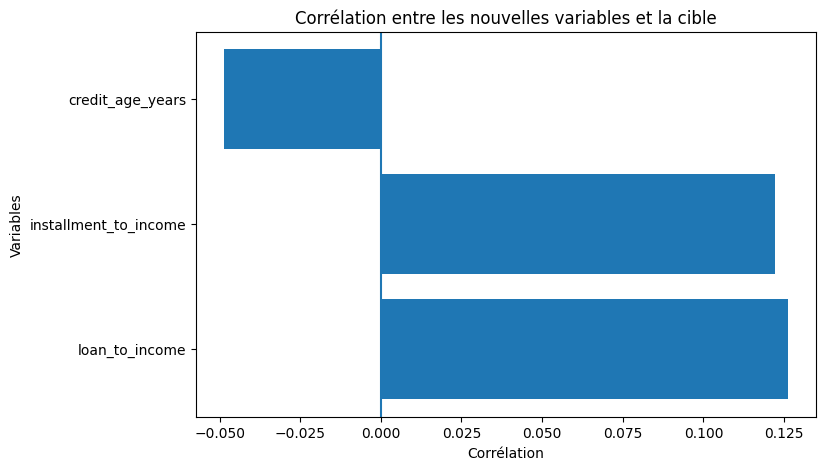

C:\Users\ebene\AppData\Local\Temp\ipykernel_24016\2859129927.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([non_defaut, defaut], labels=["Non-défaut", "Défaut"])


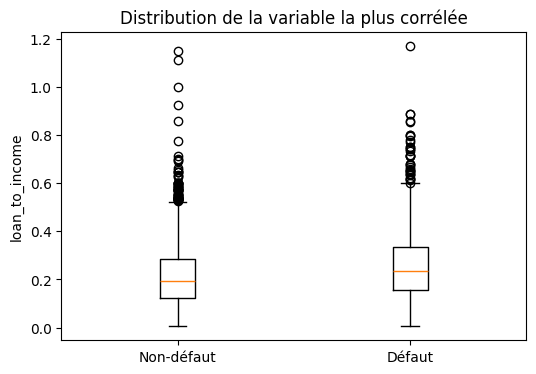

Variable la plus corrélée : loan_to_income


In [8]:
# On enlève la variable binaire is_experienced
features = []
for f in engineered_features:
    if f in df.columns and f != "is_experienced":
        features.append(f)

# Vérifier qu'il reste des variables
if len(features) > 0:

    # Calcul de la corrélation avec la variable cible
    corr_matrix = df[features + [target_col]].corr()
    corr_target = corr_matrix[target_col].drop(target_col)

    # Trier les corrélations
    corr_target = corr_target.sort_values(ascending=False)

    print("Corrélations avec la cible :")
    print(corr_target)

    # -----------------------------
    # Graphique 1 : corrélation
    # -----------------------------
    plt.figure(figsize=(8,5))
    plt.barh(corr_target.index, corr_target.values)
    plt.axvline(0)
    plt.title("Corrélation entre les nouvelles variables et la cible")
    plt.xlabel("Corrélation")
    plt.ylabel("Variables")
    plt.show()

    # -----------------------------
    # Graphique 2 : boxplot
    # -----------------------------
    # On prend la variable la plus corrélée
    top_feature = corr_target.index[0]

    # Séparer les données selon défaut / non défaut
    non_defaut = df[df[target_col] == 0][top_feature]
    defaut = df[df[target_col] == 1][top_feature]

    plt.figure(figsize=(6,4))
    plt.boxplot([non_defaut, defaut], labels=["Non-défaut", "Défaut"])
    plt.title("Distribution de la variable la plus corrélée")
    plt.ylabel(top_feature)
    plt.show()

    print("Variable la plus corrélée :", top_feature)

else:
    print("Aucune variable disponible.")

## Binary Encoding

In [13]:
# Le binary encoding (get_dummies) ne dépend pas de la cible,
# donc il peut être fait avant le split sans risque de leakage.

original_cols = df.columns.tolist()
df = pd.get_dummies(df, columns=binary_cat_cols, drop_first=True)

# Identifier les nouvelles colonnes créées par le binary encoding
new_binary_cols = [col for col in df.columns if col not in original_cols]
print(f"Nouvelles colonnes binaires créées : {new_binary_cols}")
print(f"Dimensions après binary encoding : {df.shape}")

df.head().T

Nouvelles colonnes binaires créées : ['term_ 60 months', 'pymnt_plan_y', 'initial_list_status_w', 'disbursement_method_DirectPay', 'loan_condition_Good Loan']
Dimensions après binary encoding : (67230, 94)


,0,1,2,3,4
id,39651438,16411620,45122316,125356772,88273234
loan_amnt,32000.0,9600.0,4000.0,6025.0,20000.0
int_rate,10.49,12.99,6.68,10.91,9.49
installment,6.534733,5.782039,4.819717,5.288267,6.463918
grade,B,C,A,B,B
...,...,...,...,...,...
term_ 60 months,True,False,False,False,False
pymnt_plan_y,False,False,False,False,False
initial_list_status_w,True,True,True,True,True
disbursement_method_DirectPay,False,False,False,False,False


## Train / Test split stratifié

In [23]:
# Le split DOIT être fait AVANT le target encoding et la normalisation
# pour éviter le data leakage.

stratified = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in stratified.split(df, df[target_col]):
    train_df = df.iloc[train_idx].reset_index(drop=True)
    test_df = df.iloc[test_idx].reset_index(drop=True)

# Séparation X / y
train_y = train_df[[target_col]]
test_y = test_df[[target_col]]

train_X = train_df.drop(columns=[target_col])
test_X = test_df.drop(columns=[target_col])

print(f"Train : {train_X.shape} | Ratio défaut : {train_y[target_col].mean():.2%}")
print(f"Test  : {test_X.shape}  | Ratio défaut : {test_y[target_col].mean():.2%}")

Train : (53784, 93) | Ratio défaut : 19.36%
Test  : (13446, 93)  | Ratio défaut : 19.36%


In [24]:
from category_encoders import TargetEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

pipe = Pipeline([
    ('encoder', TargetEncoder(cols=multi_cat_cols)),
    ('model', RandomForestRegressor())
])

param_grid = {'encoder__smoothing': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2')
grid.fit(train_X, train_y)

print("Meilleur smoothing :", grid.best_params_)

C:\Users\ebene\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\ebene\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\ebene\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y 

Meilleur smoothing : {'encoder__smoothing': 0.01}


In [28]:
encoder = TargetEncoder(cols=multi_cat_cols, smoothing=0.01)

# Fit UNIQUEMENT sur le train
train_X[multi_cat_cols] = encoder.fit_transform(train_X[multi_cat_cols], train_y)

# Appliquer les mêmes règles au test
test_X[multi_cat_cols] = encoder.transform(test_X[multi_cat_cols])

print("Target Encoding appliqué avec succès.")
train_X.head().T

Target Encoding appliqué avec succès.


,0,1,2,3,4
id,0.193608,0.193608,0.193608,0.193608,0.193608
loan_amnt,0.055539,2.365441,-0.76159,1.556975,-0.836661
int_rate,-1.13321,-0.223034,0.32897,-1.691536,-0.880384
installment,0.408628,1.819158,-1.006612,1.314842,-0.683717
grade,0.06735,0.213399,0.294089,0.06735,0.12734
...,...,...,...,...,...
term_ 60 months,False,False,True,False,False
pymnt_plan_y,False,False,False,False,False
initial_list_status_w,True,False,False,True,True
disbursement_method_DirectPay,False,False,False,False,False


## Normalisation

In [29]:
scaler = StandardScaler()

# Fit UNIQUEMENT sur le train
train_X[num_cols] = scaler.fit_transform(train_X[num_cols])

# Appliquer les mêmes règles au test
test_X[num_cols] = scaler.transform(test_X[num_cols])

print("Normalisation appliquée avec succès.")
train_X.head().T

Normalisation appliquée avec succès.


,0,1,2,3,4
id,0.193608,0.193608,0.193608,0.193608,0.193608
loan_amnt,0.055539,2.365441,-0.76159,1.556975,-0.836661
int_rate,-1.13321,-0.223034,0.32897,-1.691536,-0.880384
installment,0.408628,1.819158,-1.006612,1.314842,-0.683717
grade,0.06735,0.213399,0.294089,0.06735,0.12734
...,...,...,...,...,...
term_ 60 months,False,False,True,False,False
pymnt_plan_y,False,False,False,False,False
initial_list_status_w,True,False,False,True,True
disbursement_method_DirectPay,False,False,False,False,False


### Vérification

In [33]:
num_cols

['loan_amnt',
 'int_rate',
 'installment',
 'annual_inc',
 'dti',
 'delinq_2yrs',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'open_acc_6m',
 'open_act_il',
 'open_il_12m',
 'open_il_24m',
 'mths_since_rcnt_il',
 'total_bal_il',
 'il_util',
 'open_rv_12m',
 'open_rv_24m',
 'max_bal_bc',
 'all_util',
 'total_rev_hi_lim',
 'inq_fi',
 'total_cu_tl',
 'inq_last_12m',
 'acc_open_past_24mths',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'chargeoff_within_12_mths',
 'delinq_amnt',
 'mo_sin_old_il_acct',
 'mo_sin_old_rev_tl_op',
 'mo_sin_rcnt_rev_tl_op',
 'mo_sin_rcnt_tl',
 'mort_acc',
 'mths_since_recent_bc',
 'mths_since_recent_bc_dlq',
 'mths_since_recent_inq',
 'mths_since_recent_revol_delinq',
 'num_accts_ever_120_p

In [34]:
len(num_cols)

79

In [36]:
print(" VÉRIFICATIONS ")
print(f"NaN dans train_X : {train_X.isnull().sum().sum()}")
print(f"NaN dans test_X  : {test_X.isnull().sum().sum()}")
print(f"Colonnes train_X : {train_X.shape[1]}")
print(f"Colonnes test_X  : {test_X.shape[1]}")
print(f"Colonnes identiques : {list(train_X.columns) == list(test_X.columns)}")

 VÉRIFICATIONS 
NaN dans train_X : 0
NaN dans test_X  : 0
Colonnes train_X : 93
Colonnes test_X  : 93
Colonnes identiques : True


In [37]:
train_X.to_parquet("DATA/03_train_X.parquet")
train_y.to_parquet("DATA/03_train_y.parquet")
test_X.to_parquet("DATA/03_test_X.parquet")
test_y.to_parquet("DATA/03_test_y.parquet")

# Sauvegarder les transformateurs pour une réutilisation future (production)
joblib.dump(encoder, "DATA/03_encoder.pkl")
joblib.dump(scaler, "DATA/03_scaler.pkl")

print(" Tous les fichiers ont été sauvegardés avec succès !")
print("   - DATA/03_train_X.parquet")
print("   - DATA/03_train_y.parquet")
print("   - DATA/03_test_X.parquet")
print("   - DATA/03_test_y.parquet")
print("   - DATA/03_encoder.pkl")
print("   - DATA/03_scaler.pkl")

 Tous les fichiers ont été sauvegardés avec succès !
   - DATA/03_train_X.parquet
   - DATA/03_train_y.parquet
   - DATA/03_test_X.parquet
   - DATA/03_test_y.parquet
   - DATA/03_encoder.pkl
   - DATA/03_scaler.pkl
